# Ravdess data distribution

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import glob
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


In [2]:
def extract_hybrid_features(file_path, max_pad_len=128):
    # Load audio
    y, sr = librosa.load(file_path, duration=3, offset=0.5)

    # Normalize audio
    y = librosa.util.normalize(y)

    # 1. MFCC - 20
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    # Delta MFCC - 20
    mfcc_delta = librosa.feature.delta(mfcc)

    # Delta-Delta MFCC - 20
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # 2. Chroma - 12
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    # 3. RMS Energy - 1
    rms = librosa.feature.rms(y=y)

    # 4. Spectral Features - 3
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    # 5. Zero Crossing Rate - 1
    zcr = librosa.feature.zero_crossing_rate(y)

    # Combine All Features - 77
    combined = np.vstack([
        mfcc,
        mfcc_delta,
        mfcc_delta2,
        chroma,
        rms,
        centroid,
        bandwidth,
        rolloff,
        zcr
    ])

    # Padding / Truncation
    if combined.shape[1] < max_pad_len:
        pad_width = max_pad_len - combined.shape[1]
        combined = np.pad(combined, ((0,0),(0,pad_width)), mode='constant')
    else:
        combined = combined[:, :max_pad_len]

    return combined.T
    
# Full RAVDESS emotion mapping
EMOTION_MAP = {'01':'neutral', '02':'calm', '03':'happy', '04':'sad', 
               '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'}

def load_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "Actor_*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} files...")

    for file in file_list:
        emotion = EMOTION_MAP[os.path.basename(file).split('-')[2]]
        X.append(extract_hybrid_features(file))
        y.append(emotion)
            
    return np.array(X), np.array(y)


In [3]:
DATA_PATH = r"C:\Users\asus\OneDrive\Desktop\Projects\Speech_Emotion_Recognition_LSTM_RAVDESS\RAVDESS"
X_raw, y_raw = load_data(DATA_PATH)

# Scaling: We flatten to scale, then reshape back to (N, 128, 77)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.reshape(-1, X_raw.shape[-1])).reshape(X_raw.shape)

lb = LabelEncoder()
y_final = to_categorical(lb.fit_transform(y_raw))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_final, test_size=0.2, random_state=42)

print(f"Data loaded: X_train shape {X_train.shape}, y_train shape {y_train.shape}")

Extracting hybrid features from 1440 files...
Data loaded: X_train shape (1152, 128, 77), y_train shape (1152, 8)


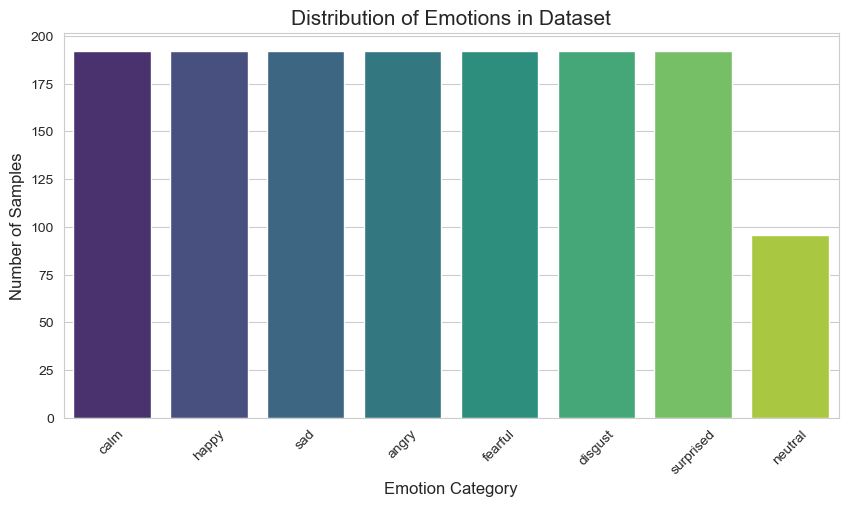

In [5]:
# import matplotlib.pyplot as plt
# import seaborn as sns

df = pd.DataFrame({'emotion': y_raw})

# 1. Set the visual style
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

# 2. Create the distribution chart
ax = sns.countplot(x='emotion', data=df, palette='viridis', order=df['emotion'].value_counts().index)

# 3. Add titles and labels
plt.title('Distribution of Emotions in Dataset', fontsize=15)
plt.xlabel('Emotion Category', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45) # Rotates labels for better readability

# 4. Show the plot
plt.show()
